In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

# Ruta a la base de datos
ruta_db = "../database/proyecto_analitica.db"

conn = sqlite3.connect(ruta_db)

df = pd.read_sql_query("SELECT * FROM jugadores", conn)
conn.close()

print("✅ Datos cargados. Dimensiones:", df.shape)
df.head()

✅ Datos cargados. Dimensiones: (144048, 22)


,id_observacion,player_id,fecha_valoracion,valor_mercado_eur_TARGET,edad_al_momento,mes_de_nacimiento,altura_cm,pie_habil,posicion_principal,nacionalidad,...,goles_12m,asistencias_12m,tarjetas_amarillas_12m,tarjetas_rojas_12m,participacion_goles_p90,partidos_seleccion_12m,convocatorias_historicas_seleccion,dias_para_fin_contrato,valor_maximo_historico_previo,liga_actual
0,Ante Matej Juric_2022,927331,2022-12-18,100000,20.060233,11.0,190.0,right,Centre-Forward,Croatia,...,0,0,0,0,0.0,0,0.0,2021.0,1000000.0,KR1
1,Emil Hallfredsson_2022,22673,2022-12-19,225000,38.472279,6.0,185.0,left,Central Midfield,Iceland,...,0,0,0,0,0.0,0,0.0,193.0,3500000.0,IT1
2,Stephan Schröck_2022,27611,2022-12-19,200000,36.328542,8.0,170.0,right,Attacking Midfield,Philippines,...,0,0,0,0,0.0,0,0.0,NaN,2000000.0,L1
3,Nick Proschwitz_2022,31535,2022-12-19,125000,36.057495,11.0,192.0,right,Centre-Forward,Germany,...,0,0,0,0,0.0,0,0.0,193.0,3000000.0,L1
4,Guido Kocer_2022,33668,2022-12-19,100000,34.258727,9.0,175.0,left,Left Winger,Turkey,...,0,0,0,0,0.0,0,0.0,924.0,2000000.0,TR1


In [ ]:
# TRANSFORMACIÓN LOGARÍTMICA DEL TARGET
df['log_valor_mercado'] = np.log1p(df['valor_mercado_eur_TARGET'])

# Visualizar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['valor_mercado_eur_TARGET'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución original')
axes[0].set_xlabel('Valor (€)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['log_valor_mercado'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Distribución log-transformada (log1p)')
axes[1].set_xlabel('log(1 + Valor)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('Asimetría original:', df['valor_mercado_eur_TARGET'].skew())
print('Asimetría después de log1p:', df['log_valor_mercado'].skew())

# NOTA: Usar 'log_valor_mercado' como target. Para volver a euros: np.expm1(prediccion)


In [2]:
# Identificamos numéricas y categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Limpiar: id_observacion, player_id, fecha_valoracion no son predictoras
id_cols = ['id_observacion', 'player_id', 'fecha_valoracion']
num_cols = [c for c in num_cols if c not in id_cols]
cat_cols = [c for c in cat_cols if c not in id_cols]

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)
print("Target:", 'valor_mercado_eur_TARGET')

Variables numéricas: ['valor_mercado_eur_TARGET', 'edad_al_momento', 'mes_de_nacimiento', 'altura_cm', 'minutos_jugados_12m', 'partidos_jugados_12m', 'goles_12m', 'asistencias_12m', 'tarjetas_amarillas_12m', 'tarjetas_rojas_12m', 'participacion_goles_p90', 'partidos_seleccion_12m', 'convocatorias_historicas_seleccion', 'dias_para_fin_contrato', 'valor_maximo_historico_previo']
Variables categóricas: ['pie_habil', 'posicion_principal', 'nacionalidad', 'liga_actual']
Target: valor_mercado_eur_TARGET


In [4]:
desc_num = df[num_cols].describe().T
desc_num['mediana'] = df[num_cols].median()
desc_num = desc_num[['mean', 'mediana', 'std', 'min', 'max']]
print("Estadísticas numéricas:")
display(desc_num.round(2))

Estadísticas numéricas:


,mean,mediana,std,min,max
valor_mercado_eur_TARGET,2940868.56,600000.00,8406198.84,10000.0,2.000000e+08
edad_al_momento,25.69,25.16,4.65,15.8,4.537000e+01
mes_de_nacimiento,5.82,5.00,3.40,1.0,1.200000e+01
altura_cm,182.24,183.00,7.48,17.0,2.100000e+02
minutos_jugados_12m,520.08,0.00,903.94,0.0,5.244000e+03
partidos_jugados_12m,8.02,0.00,12.65,0.0,6.200000e+01
goles_12m,0.78,0.00,2.44,0.0,5.600000e+01
asistencias_12m,0.60,0.00,1.67,0.0,3.700000e+01
tarjetas_amarillas_12m,1.08,0.00,2.19,0.0,2.000000e+01
tarjetas_rojas_12m,0.03,0.00,0.18,0.0,4.000000e+00


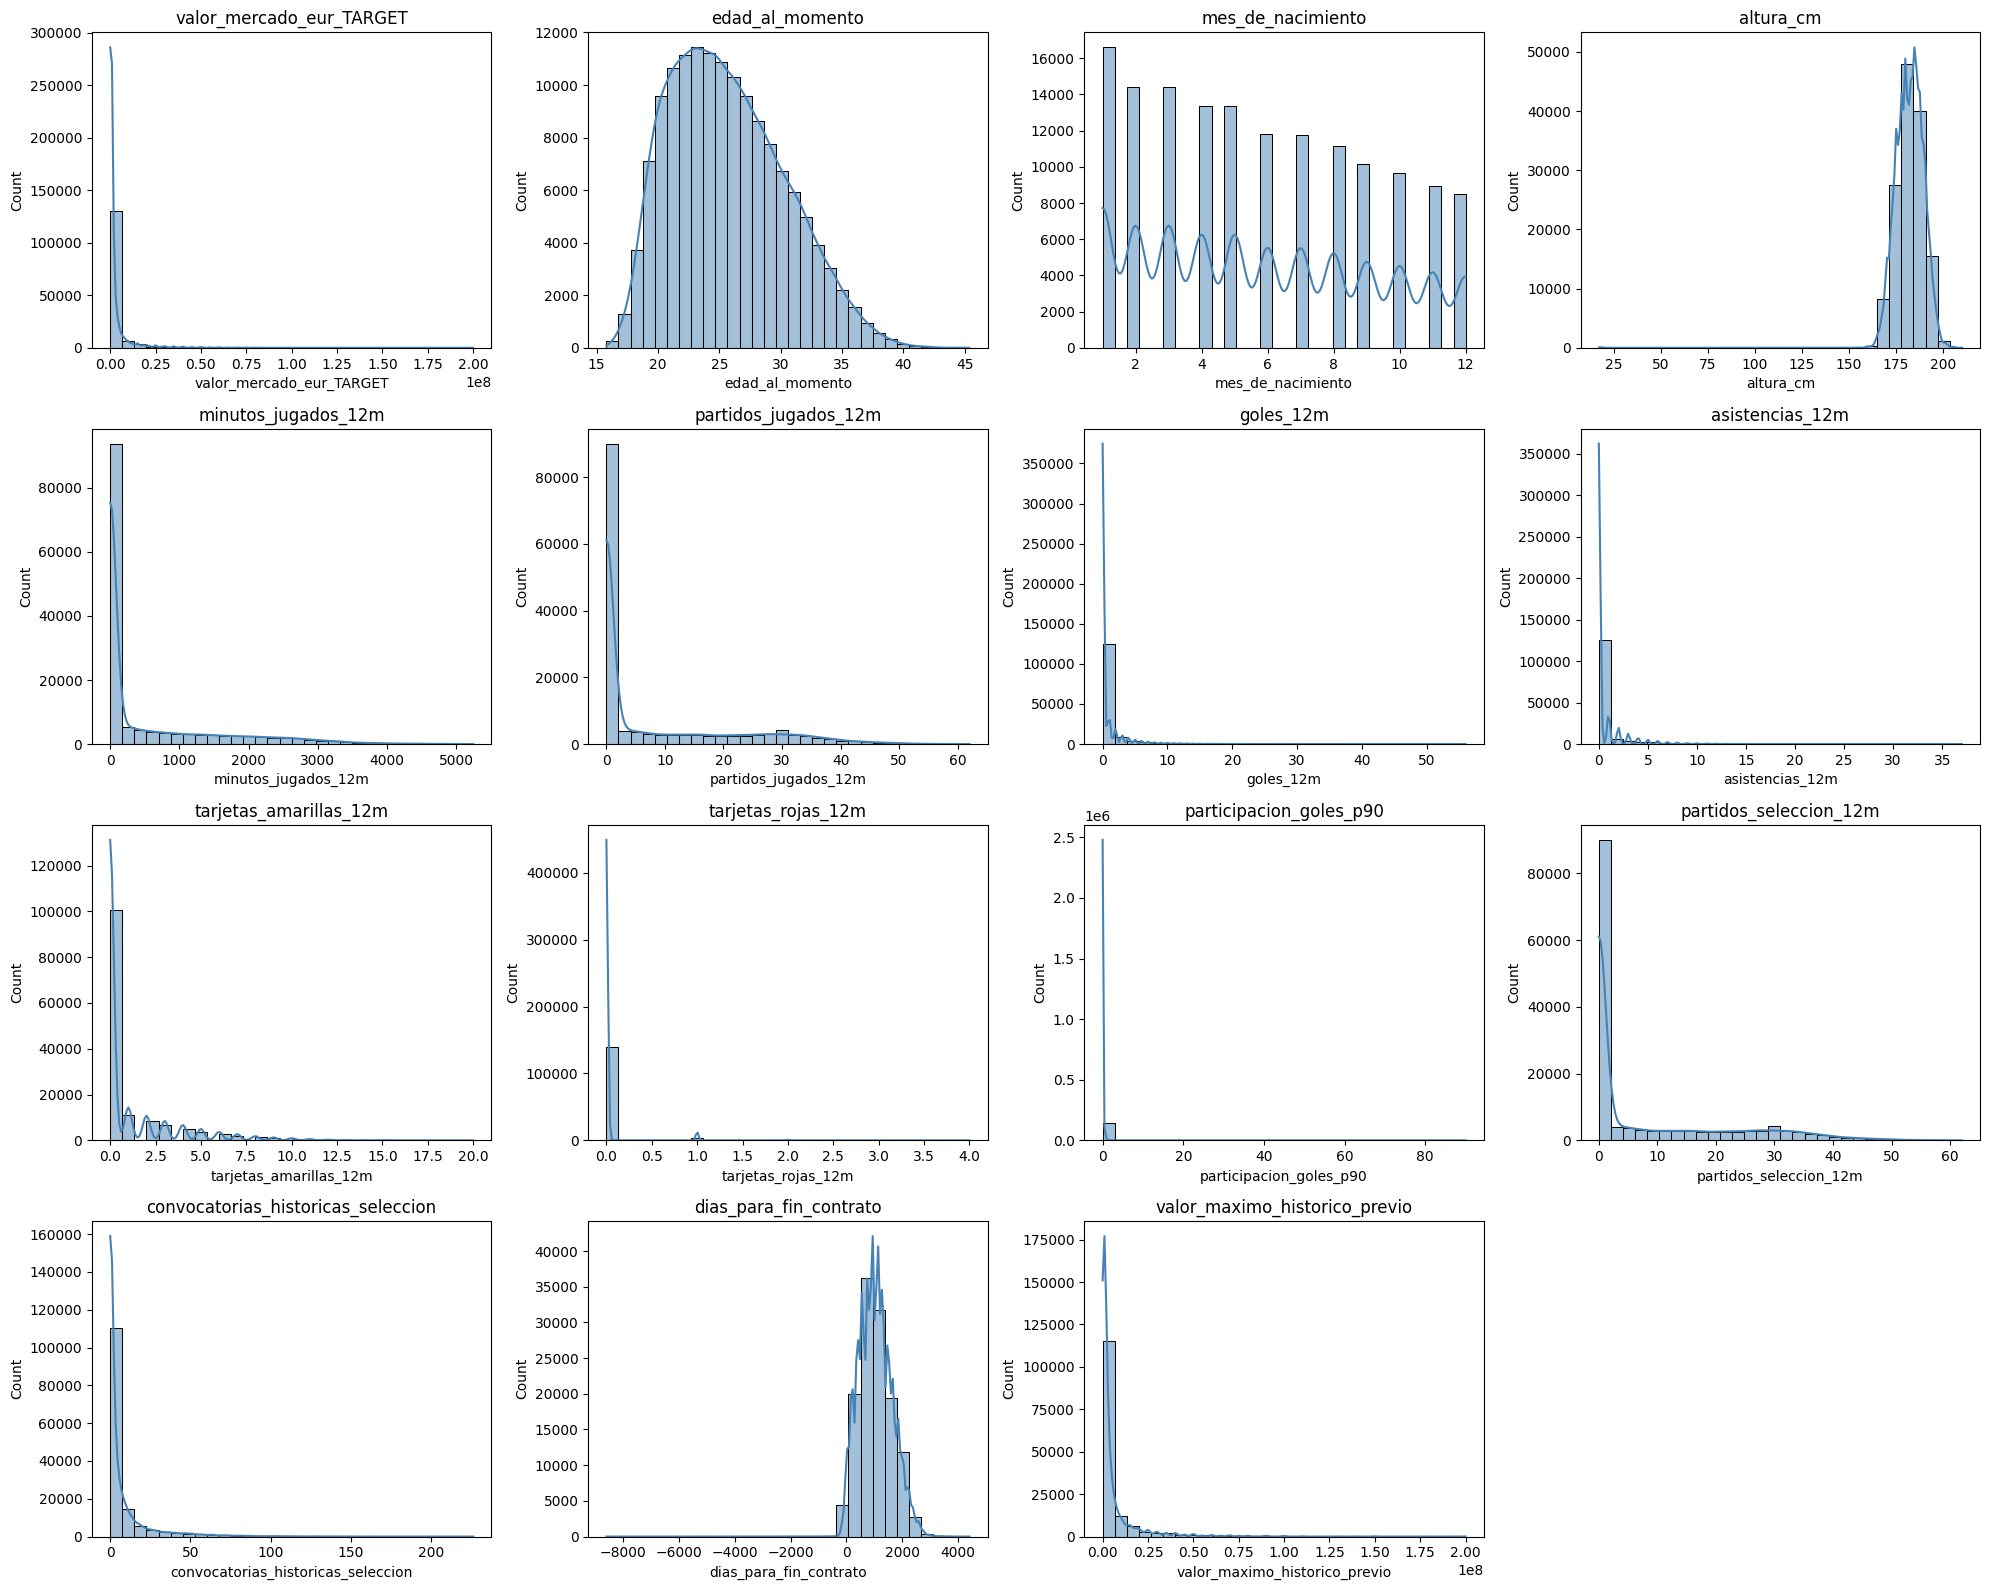

In [5]:
import math
n_vars = len(num_cols)
n_rows = math.ceil(n_vars / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows*4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

🔍 Detección de outliers (IQR):
valor_mercado_eur_TARGET: 18870 outliers (13.10%)
edad_al_momento: 365 outliers (0.25%)
mes_de_nacimiento: 0 outliers (0.00%)
altura_cm: 287 outliers (0.20%)
minutos_jugados_12m: 17627 outliers (12.24%)
partidos_jugados_12m: 7212 outliers (5.01%)
goles_12m: 30046 outliers (20.86%)
asistencias_12m: 29859 outliers (20.73%)
tarjetas_amarillas_12m: 24313 outliers (16.88%)
tarjetas_rojas_12m: 3990 outliers (2.77%)
participacion_goles_p90: 28406 outliers (19.72%)
partidos_seleccion_12m: 7212 outliers (5.01%)
convocatorias_historicas_seleccion: 17425 outliers (12.10%)
dias_para_fin_contrato: 227 outliers (0.16%)
valor_maximo_historico_previo: 19042 outliers (13.22%)


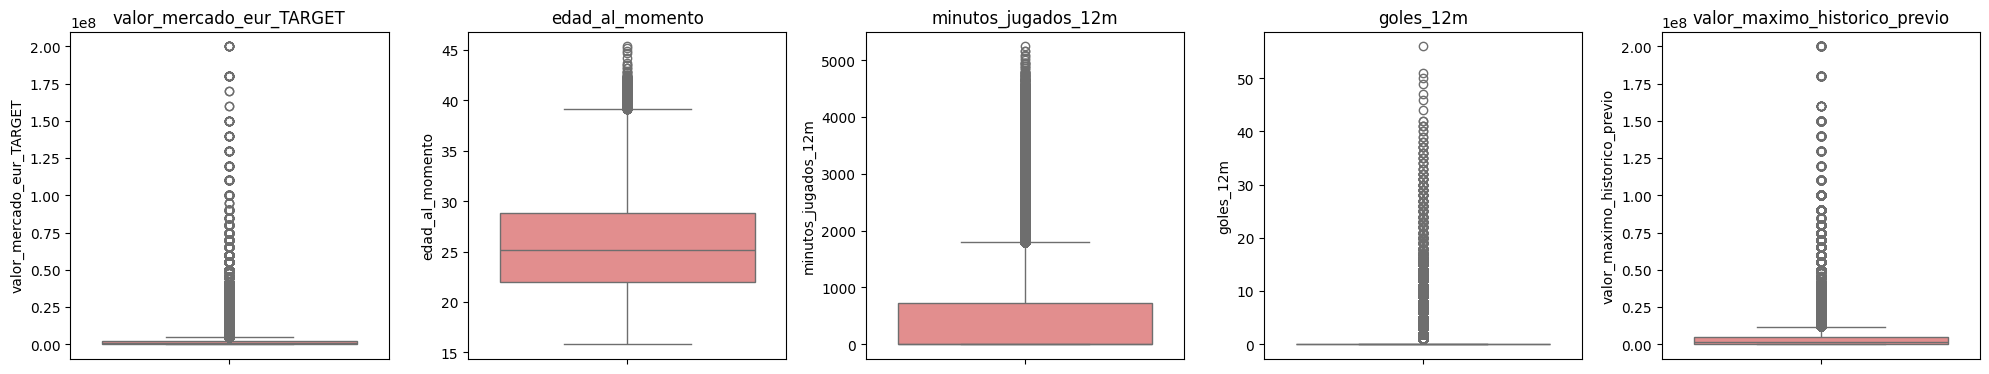

In [6]:
print("🔍 Detección de outliers (IQR):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

# Boxplots de las principales (evita saturar)
main_cols = ['valor_mercado_eur_TARGET', 'edad_al_momento', 'minutos_jugados_12m', 
             'goles_12m', 'valor_maximo_historico_previo']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(main_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

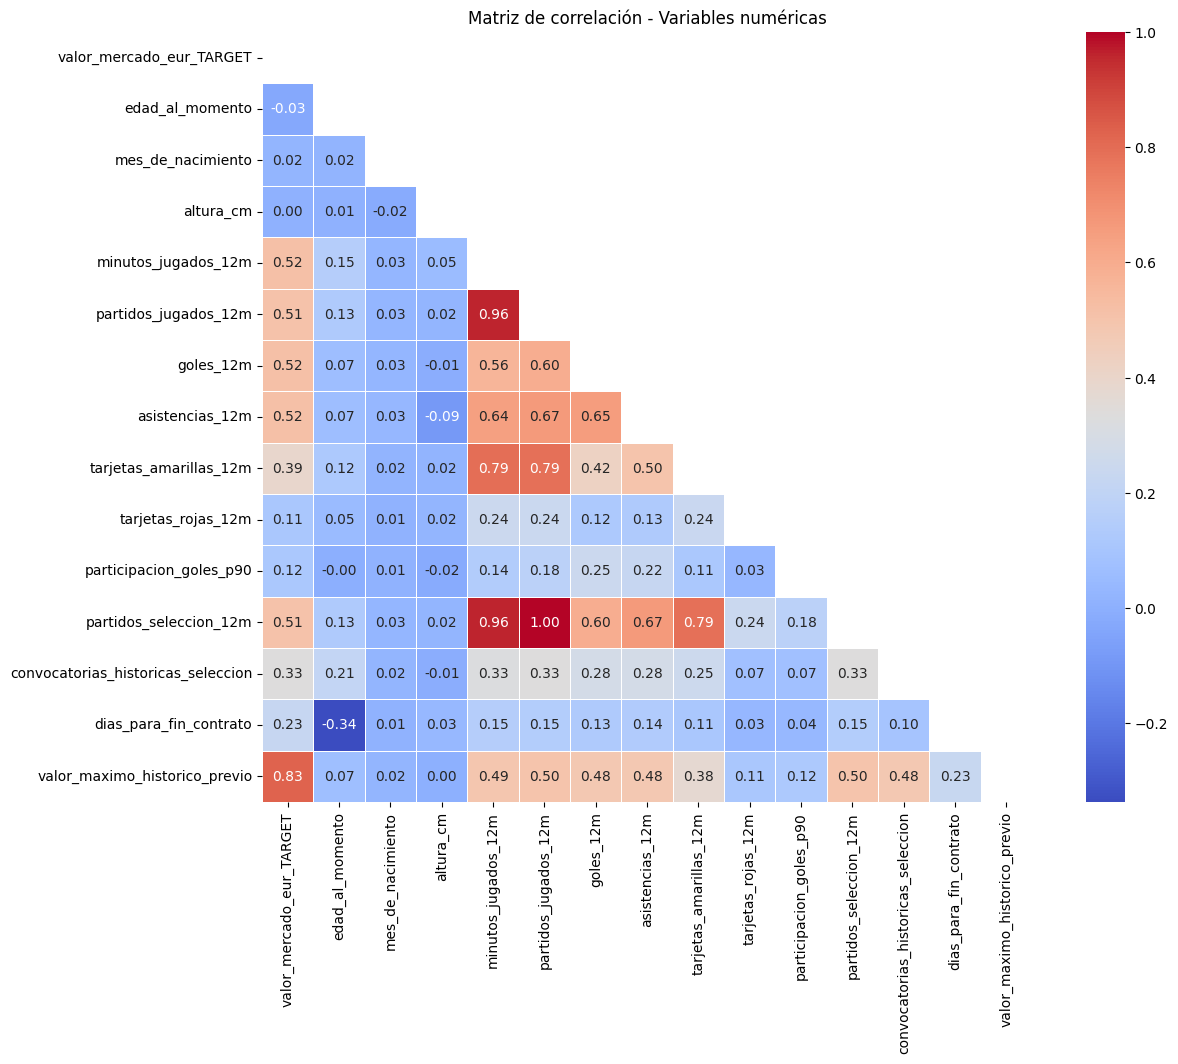

Correlación con el target (valor_mercado_eur_TARGET):
valor_mercado_eur_TARGET              1.000000
valor_maximo_historico_previo         0.825300
goles_12m                             0.519209
asistencias_12m                       0.517875
minutos_jugados_12m                   0.515394
partidos_jugados_12m                  0.508015
partidos_seleccion_12m                0.508015
tarjetas_amarillas_12m                0.394048
convocatorias_historicas_seleccion    0.332306
dias_para_fin_contrato                0.226647
participacion_goles_p90               0.115198
tarjetas_rojas_12m                    0.108474
mes_de_nacimiento                     0.022550
altura_cm                             0.003616
edad_al_momento                      -0.033024
Name: valor_mercado_eur_TARGET, dtype: float64


In [7]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title("Matriz de correlación - Variables numéricas")
plt.show()

# Correlación con el target (ordenada)
corr_target = corr_matrix['valor_mercado_eur_TARGET'].sort_values(ascending=False)
print("Correlación con el target (valor_mercado_eur_TARGET):")
print(corr_target)

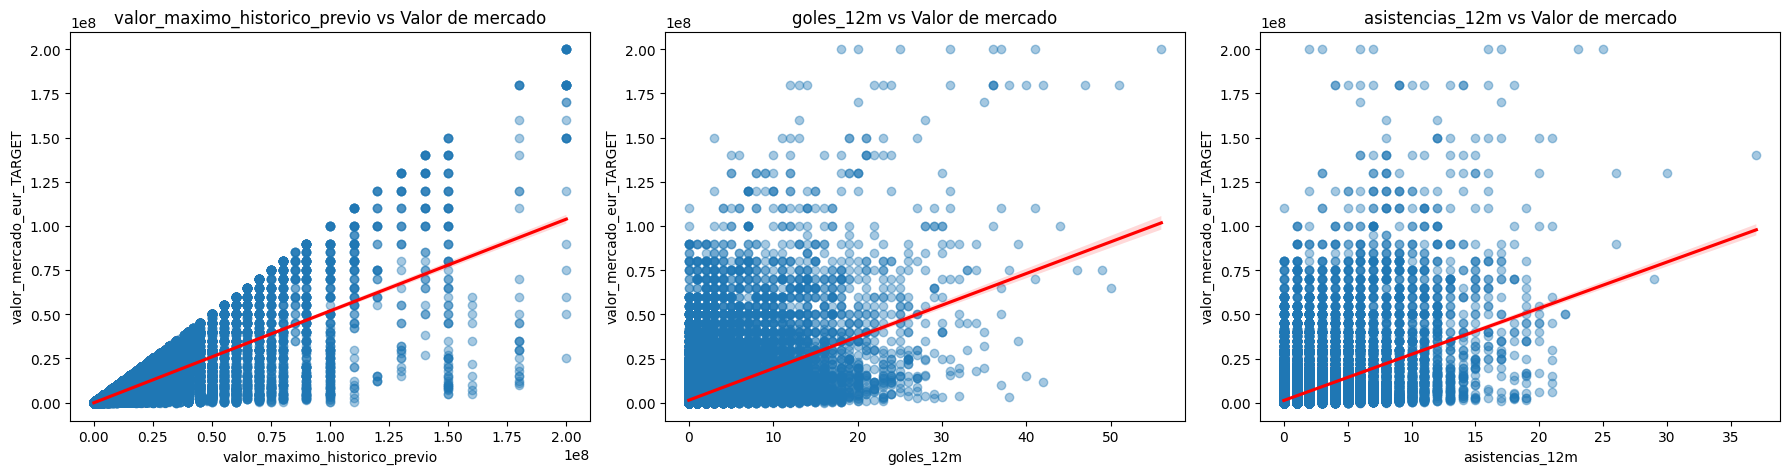

In [8]:
# ================================
# 6. RELACIONES (scatter plots vs target)
# ================================
top3 = corr_target.index[1:4]  # las 3 más correlacionadas (excluyendo el propio target)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(top3):
    sns.regplot(data=df, x=col, y='valor_mercado_eur_TARGET', ax=axes[i],
                scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    axes[i].set_title(f"{col} vs Valor de mercado")
plt.tight_layout()
plt.show()

In [10]:
# Importar librerías necesarias
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
import sqlite3
import numpy as np

ruta_db = "../database/proyecto_analitica.db"
conn = sqlite3.connect(ruta_db)
df = pd.read_sql_query("SELECT * FROM jugadores", conn)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
conn.close()


C:\Users\user\AppData\Local\Temp\ipykernel_23728\4011892498.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
# ==========================================
# 1. IDENTIFICAR VALORES FALTANTES
# ==========================================
print("--- Conteo de Valores Faltantes ---")
faltantes = df.isnull().sum()
faltantes_cols = faltantes[faltantes > 0]

if faltantes_cols.empty:
    print("¡No hay valores faltantes en el dataset!")
else:
    print(faltantes_cols)
    print(f"\nPorcentaje de datos faltantes:\n{(faltantes_cols / len(df) * 100).round(2)}%")

# Solo procedemos si hay numéricas con NAs (evitamos romper el código con categóricas)
cols_imputar = [col for col in faltantes_cols.index if col in num_cols]

if cols_imputar:
    # ==========================================
    # 2. APLICAR DOS MÉTODOS DE IMPUTACIÓN
    # ==========================================
    print("\nIniciando imputación...")
    
    # Copias para no afectar el dataset original de MOMENTO
    df_imputado_mediana = df.copy()
    df_imputado_knn = df.copy()
    
    # Método A: Tendencia Central (Mediana es más robusta a outliers que la media)
    imputer_mediana = SimpleImputer(strategy='median')
    df_imputado_mediana[cols_imputar] = imputer_mediana.fit_transform(df[cols_imputar])
    
    # Método B: KNN Imputer (Usa IterativeImputer si tu RAM colapsa en el de ajedrez)
    # imputer_avanzado = IterativeImputer(max_iter=10, random_state=42) # Alternativa rápida
    imputer_avanzado = KNNImputer(n_neighbors=5)
    df_imputado_knn[cols_imputar] = imputer_avanzado.fit_transform(df[cols_imputar])
    print("Imputación finalizada.")

    # ==========================================
    # 3. COMPARAR RESULTADOS (Antes y Después)
    # ==========================================
    print("\n--- Comparación de Estadísticas Descriptivas ---")
    for col in cols_imputar:
        print(f"\nVariable: {col}")
        comp_df = pd.DataFrame({
            'Original (con NAs)': df[col].describe(),
            'Imputado Mediana': df_imputado_mediana[col].describe(),
            'Imputado KNN': df_imputado_knn[col].describe()
        })
        display(comp_df.round(2))
        
        # Comparación visual (Distribución KDE)
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df, x=col, label='Original', fill=True, alpha=0.3, color='blue')
        sns.kdeplot(data=df_imputado_mediana, x=col, label='Mediana', fill=False, color='red', linestyle='--')
        sns.kdeplot(data=df_imputado_knn, x=col, label='KNN', fill=False, color='green', linestyle=':')
        plt.title(f"Impacto de la imputación en la distribución de '{col}'")
        plt.legend()
        plt.show()
        


--- Conteo de Valores Faltantes ---
edad_al_momento              11
mes_de_nacimiento            11
altura_cm                  3273
pie_habil                  6961
nacionalidad                388
dias_para_fin_contrato    17264
liga_actual               23410
dtype: int64

Porcentaje de datos faltantes:
edad_al_momento            0.01
mes_de_nacimiento          0.01
altura_cm                  2.27
pie_habil                  4.83
nacionalidad               0.27
dias_para_fin_contrato    11.98
liga_actual               16.25
dtype: float64%

Iniciando imputación...


NameError: name 'SimpleImputer' is not defined

Tras evaluar el impacto de ambos métodos en la distribución de las variables numéricas, se determina que el método de imputación multivariable (KNN Imputer) es el más adecuado por lo siguientes motivos:

Preservación de la varianza: En variables con un porcentaje significativo de datos faltantes, como dias_para_fin_contrato (11.98%) y altura_cm (2.27%), la imputación por la Mediana genera una distorsión crítica en la distribución de los datos. Como se observa en los gráficos KDE, la mediana inyecta miles de valores idénticos en la "mitad"

Reconstrucción contextual: KNN Imputer logra imputar los valores ausentes calculando distancias con los "vecinos más cercanos". Esto significa que si a un jugador le falta la estatura, el modelo buscará a otros jugadores con edad, posición o características físicas similares para estimarla.

Mantiene mejor la distribución original

--- 1. Imputando variables categóricas (Vía Moda) ---
✅ Imputación categórica lista. Nulos restantes:
pie_habil       0
nacionalidad    0
liga_actual     0
dtype: int64




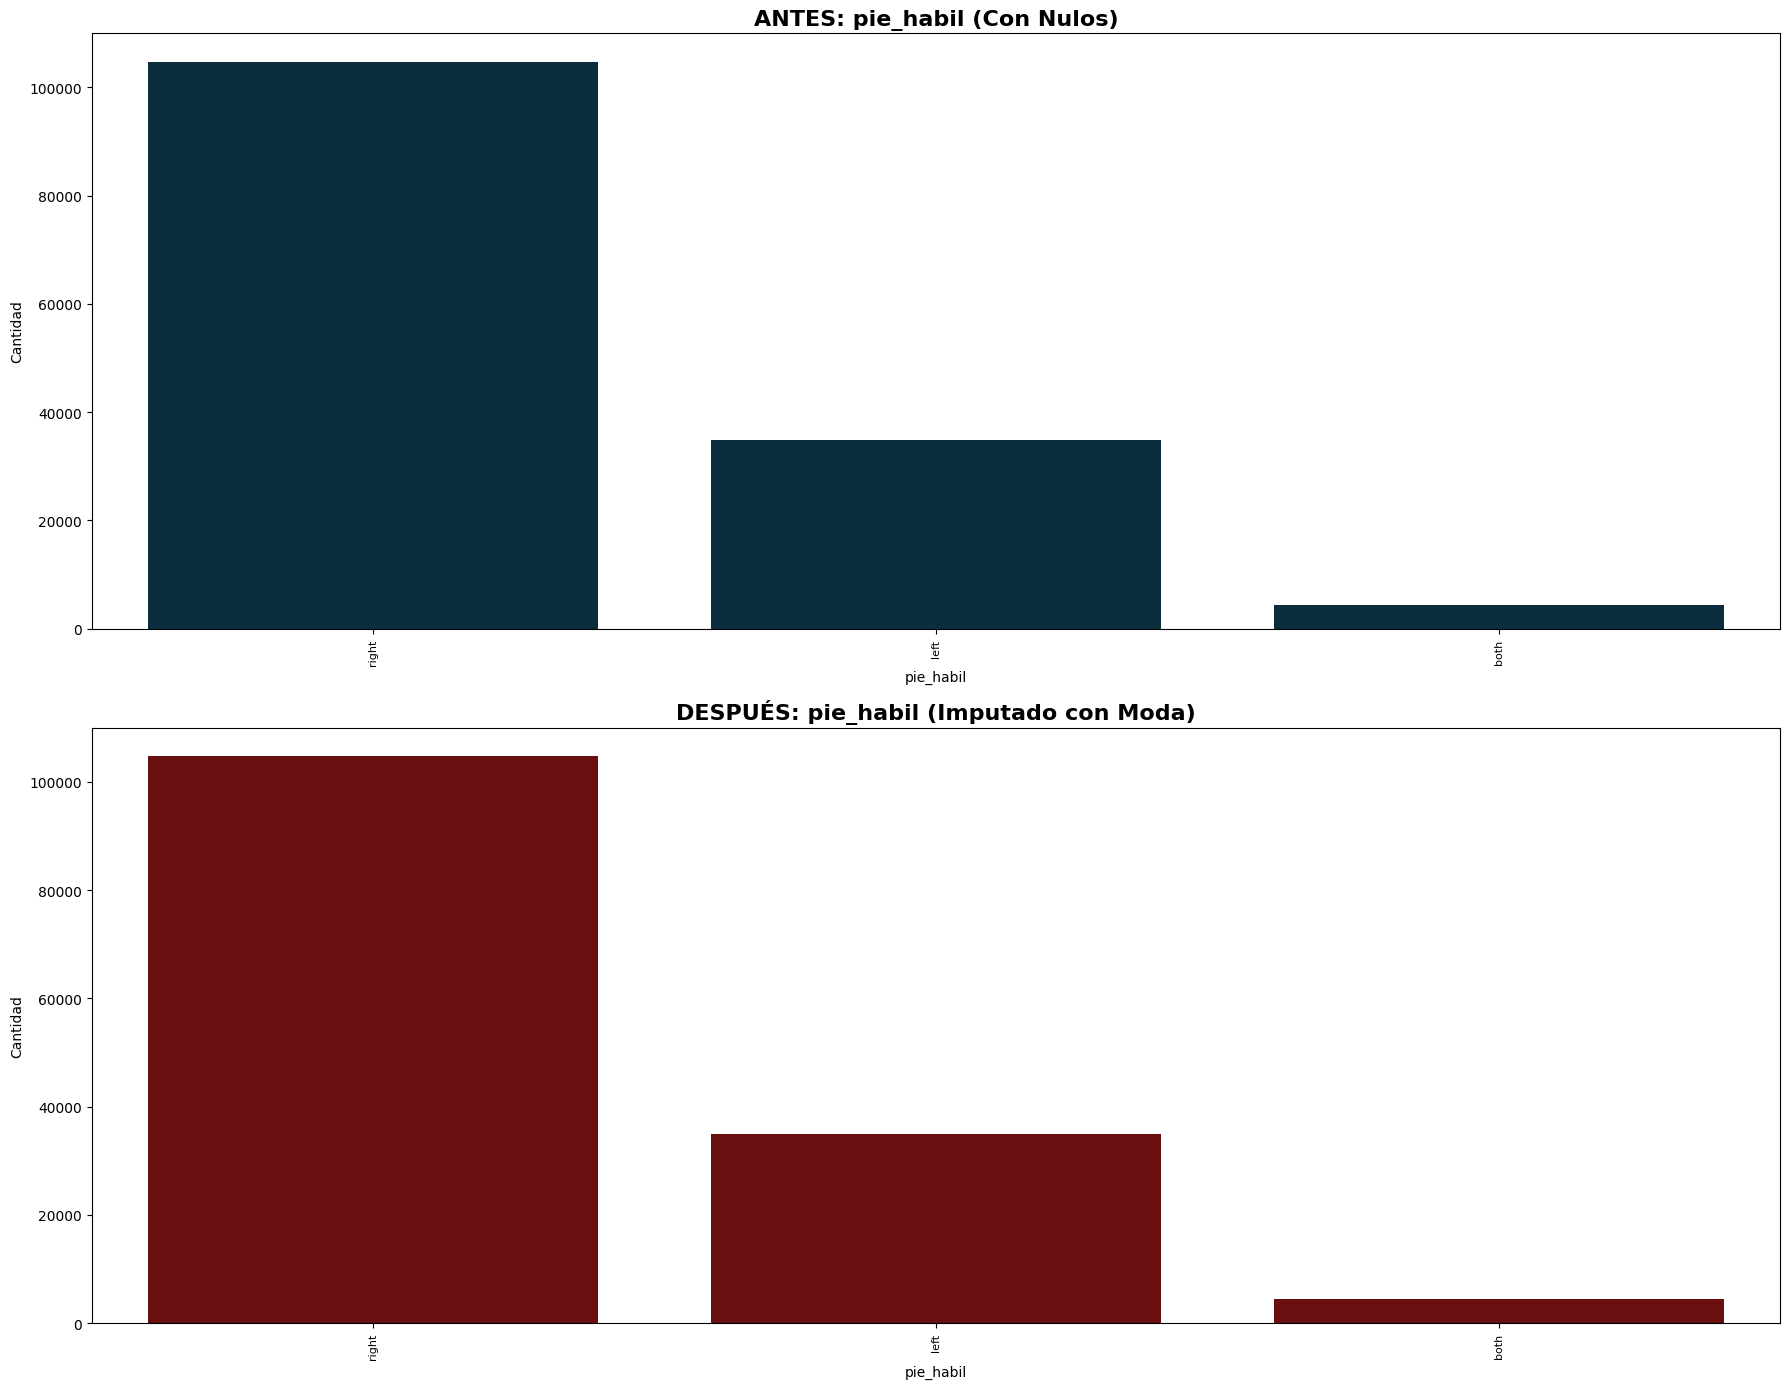

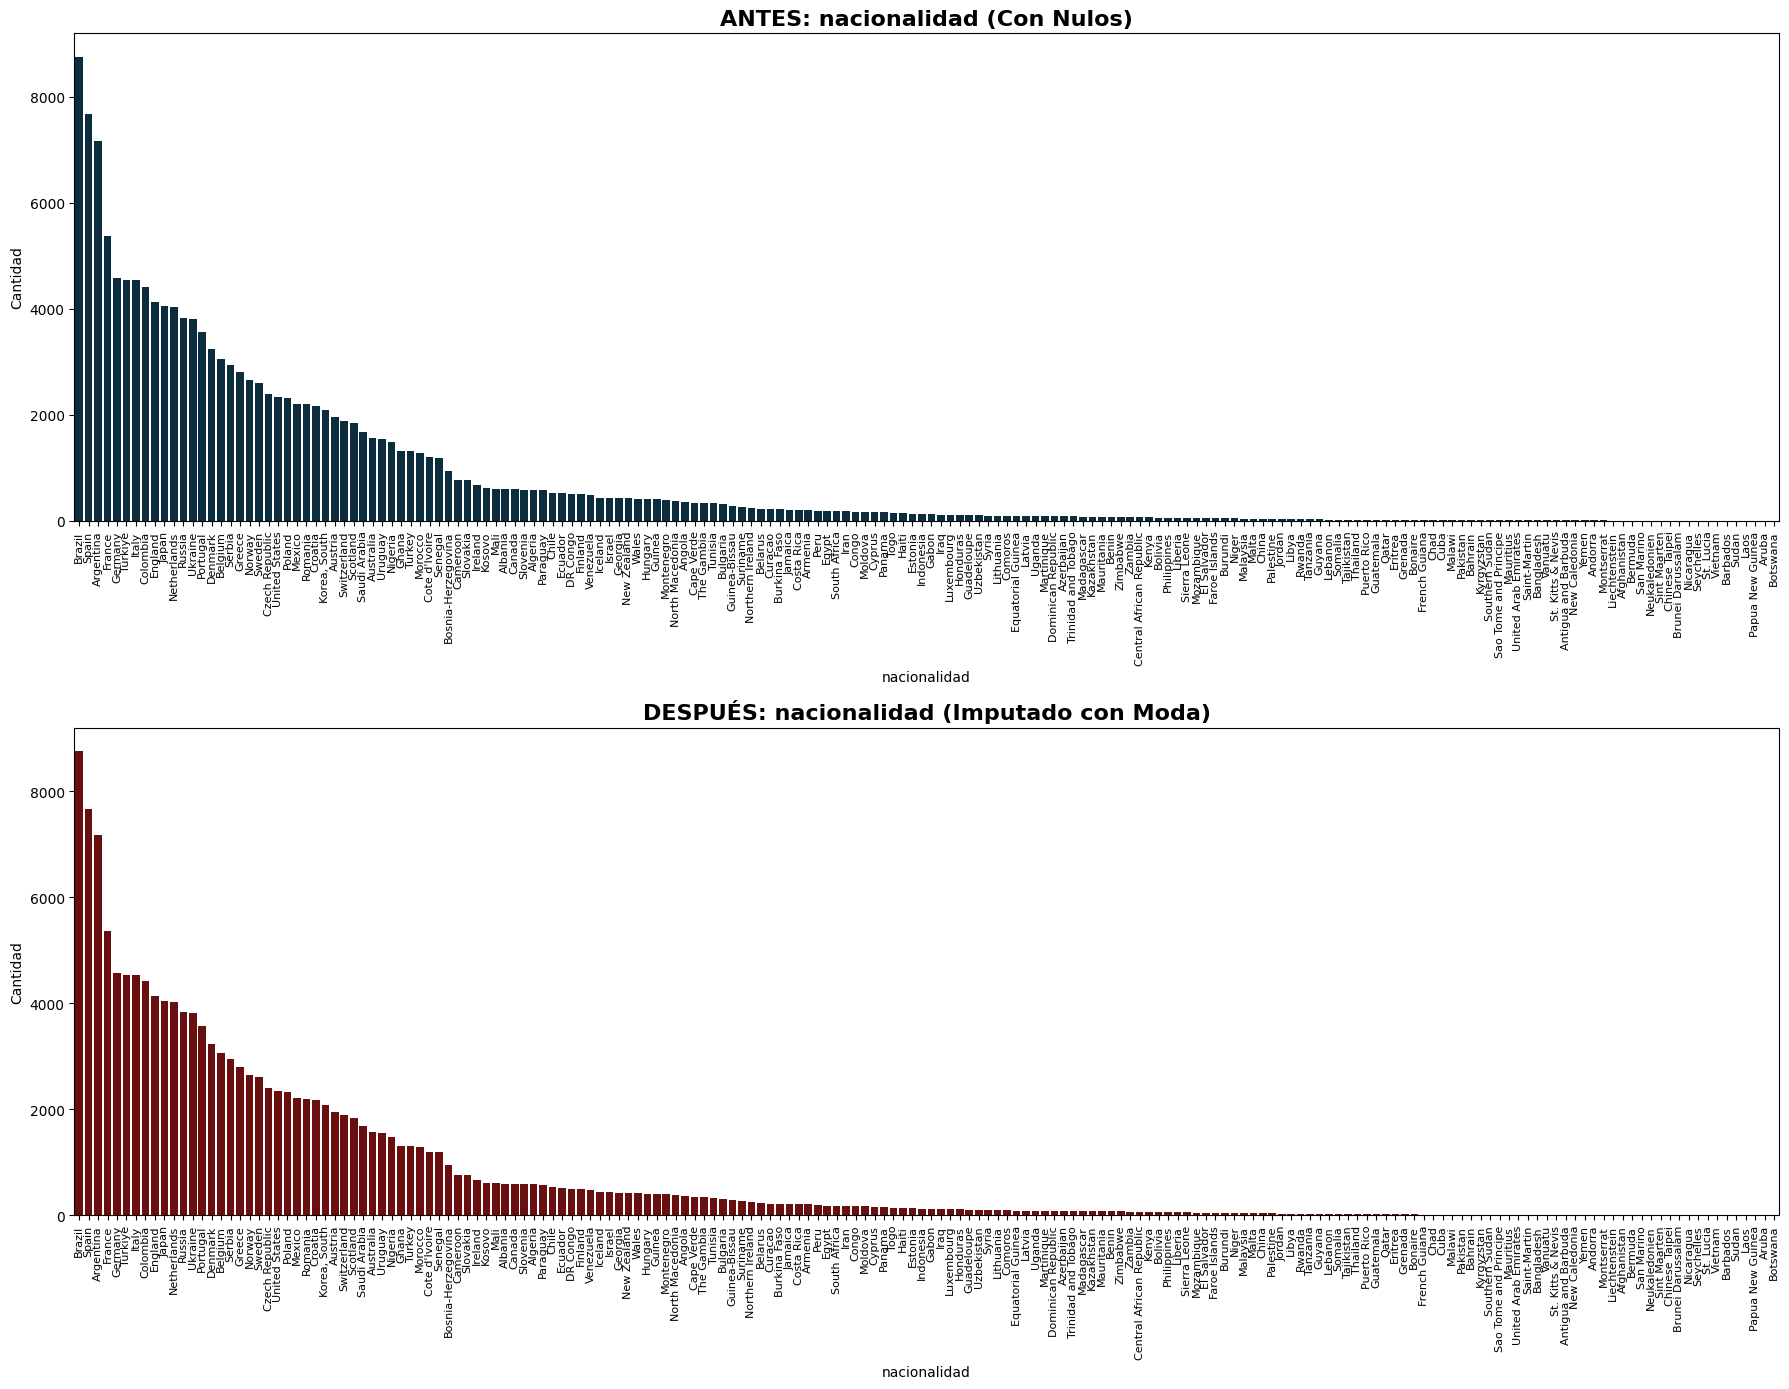

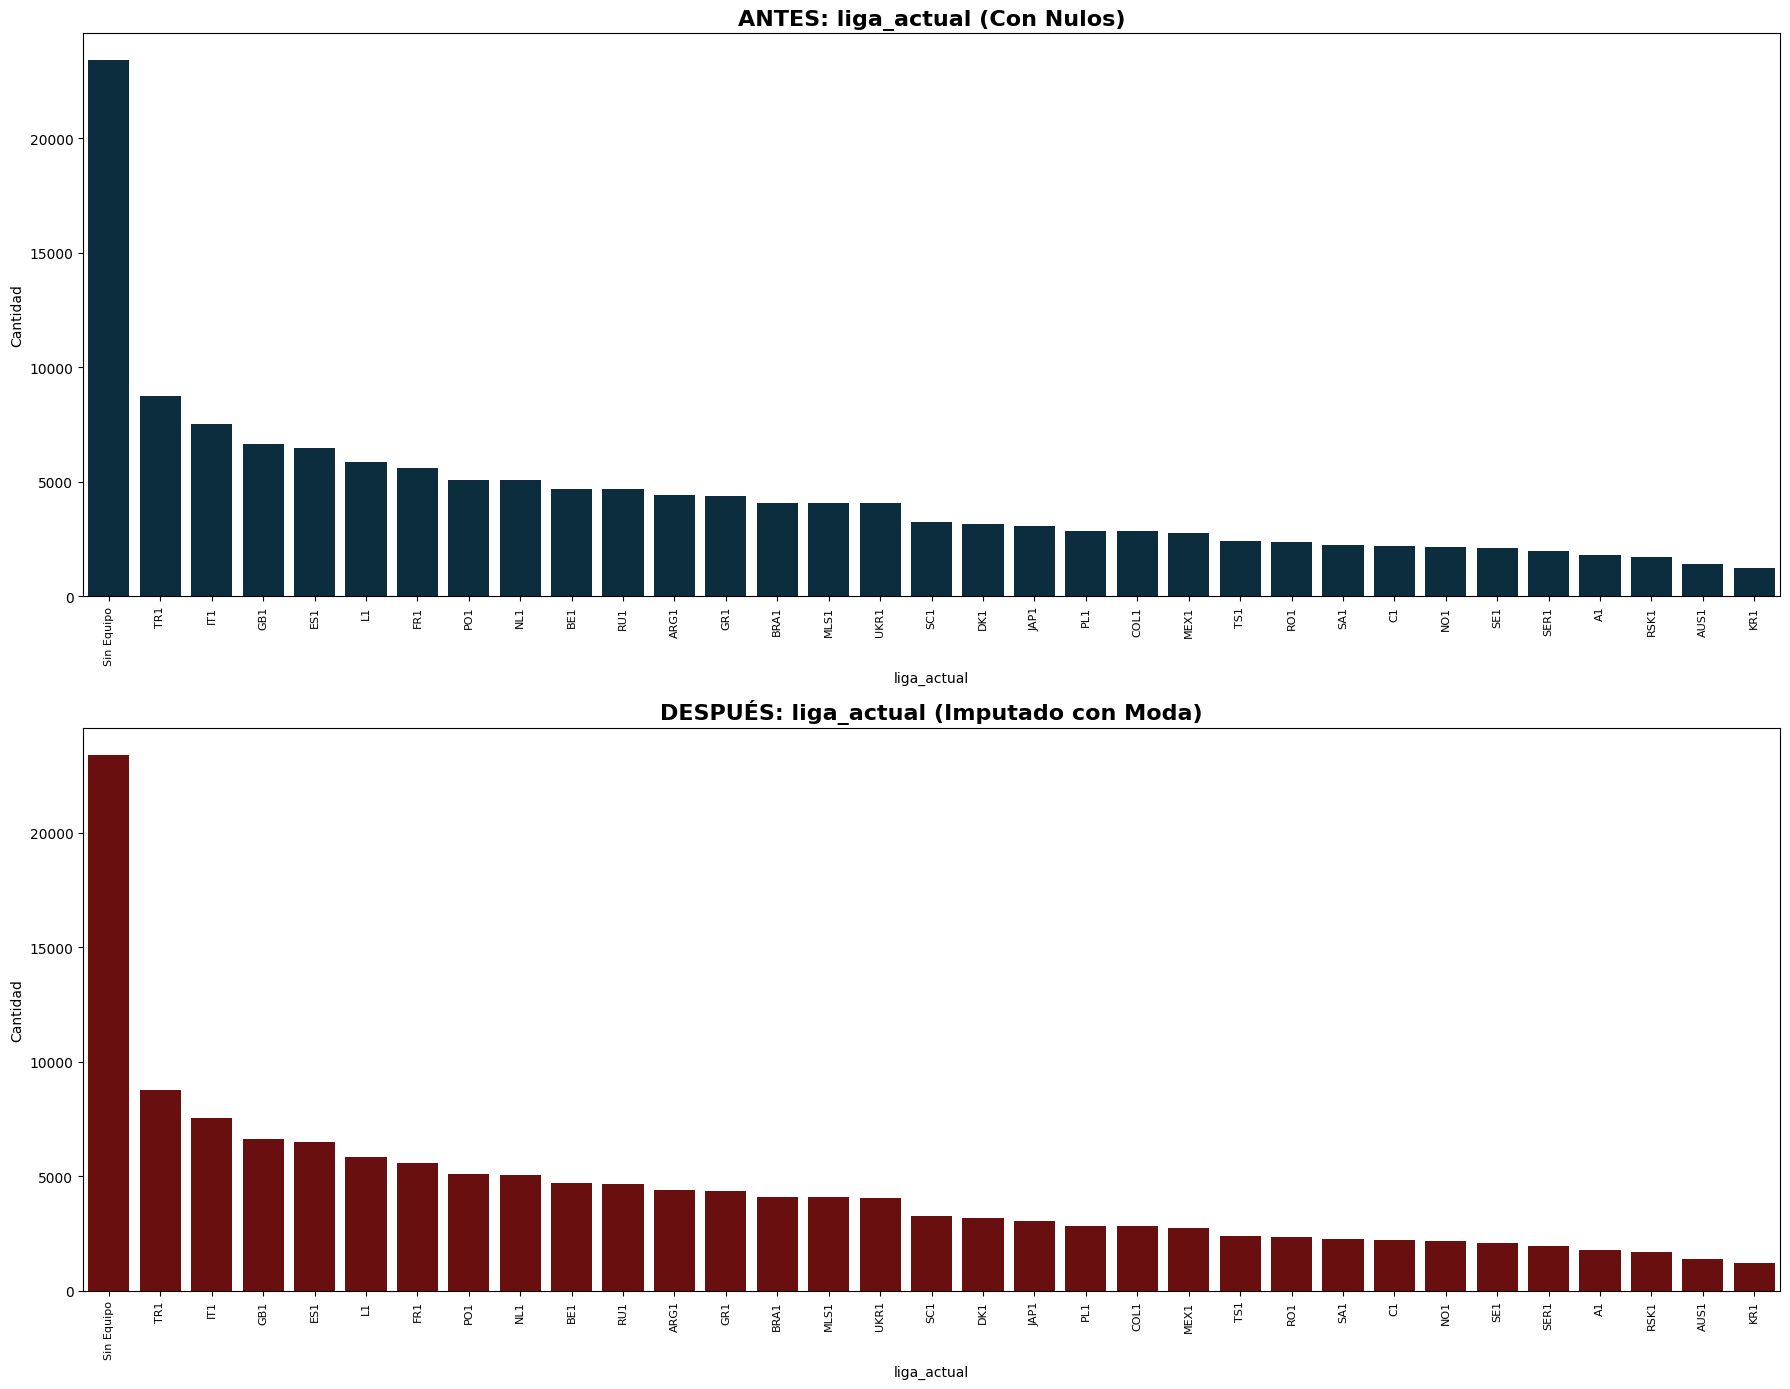

--- 2. Conteo de Valores Faltantes (Numéricas) ---
edad_al_momento              11
mes_de_nacimiento            11
altura_cm                  3273
dias_para_fin_contrato    17264
dtype: int64

Porcentaje de datos faltantes:
edad_al_momento            0.01
mes_de_nacimiento          0.01
altura_cm                  2.27
dias_para_fin_contrato    11.98
dtype: float64%

--- 3. Iniciando imputación de variables numéricas ---
⏳ Calculando KNN usando todos los núcleos del procesador (n_jobs=-1)...
✅ Imputación numérica multihilo finalizada.

--- 4. Comparación de Estadísticas Descriptivas ---

================ Variable: edad_al_momento ================


c:\Users\user\Desktop\ml-project_analitica_datos\venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Original (con NAs),Imputado Mediana,Imputado KNN Multi
count,144037.00,144048.00,144048.00
mean,25.69,25.69,25.69
std,4.65,4.65,4.65
min,15.80,15.80,15.80
25%,22.01,22.01,22.01
50%,25.16,25.16,25.16
75%,28.87,28.87,28.87
max,45.37,45.37,45.37


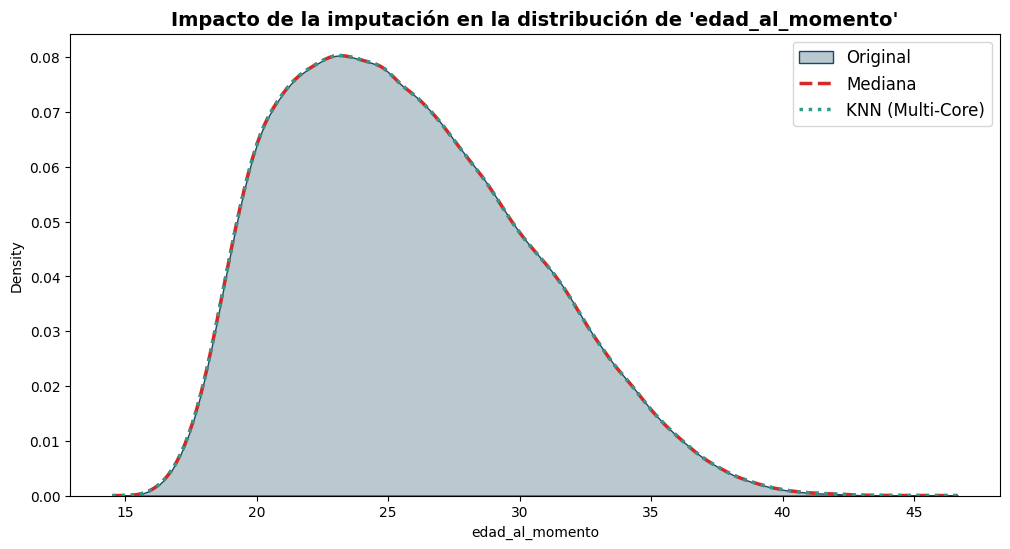


================ Variable: mes_de_nacimiento ================


,Original (con NAs),Imputado Mediana,Imputado KNN Multi
count,144037.00,144048.00,144048.00
mean,5.82,5.82,5.82
std,3.40,3.40,3.40
min,1.00,1.00,1.00
25%,3.00,3.00,3.00
50%,5.00,5.00,5.00
75%,9.00,9.00,9.00
max,12.00,12.00,12.00


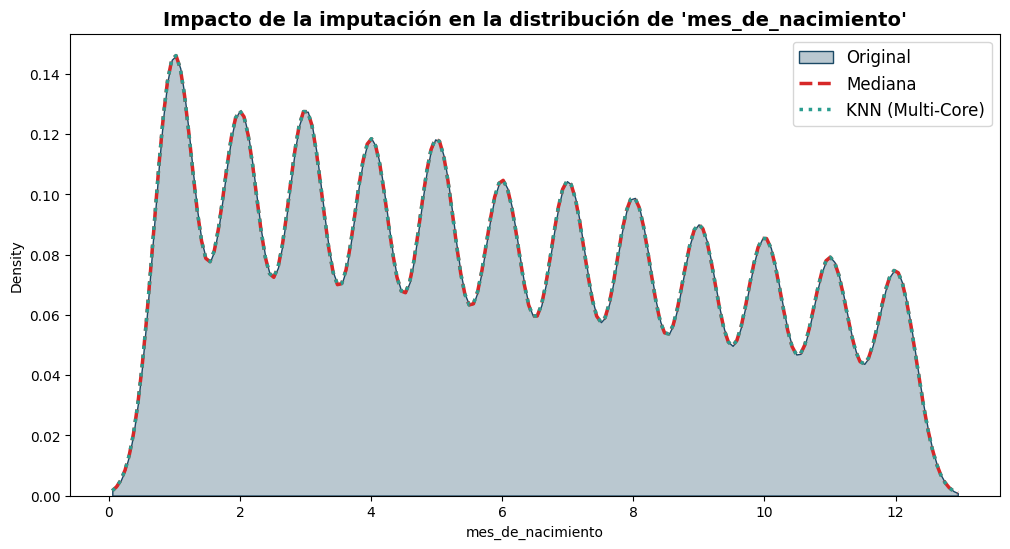


================ Variable: altura_cm ================


,Original (con NAs),Imputado Mediana,Imputado KNN Multi
count,140775.00,144048.00,144048.00
mean,182.24,182.25,182.24
std,7.48,7.40,7.42
min,17.00,17.00,17.00
25%,177.00,177.00,177.00
50%,183.00,183.00,183.00
75%,187.00,187.00,187.00
max,210.00,210.00,210.00


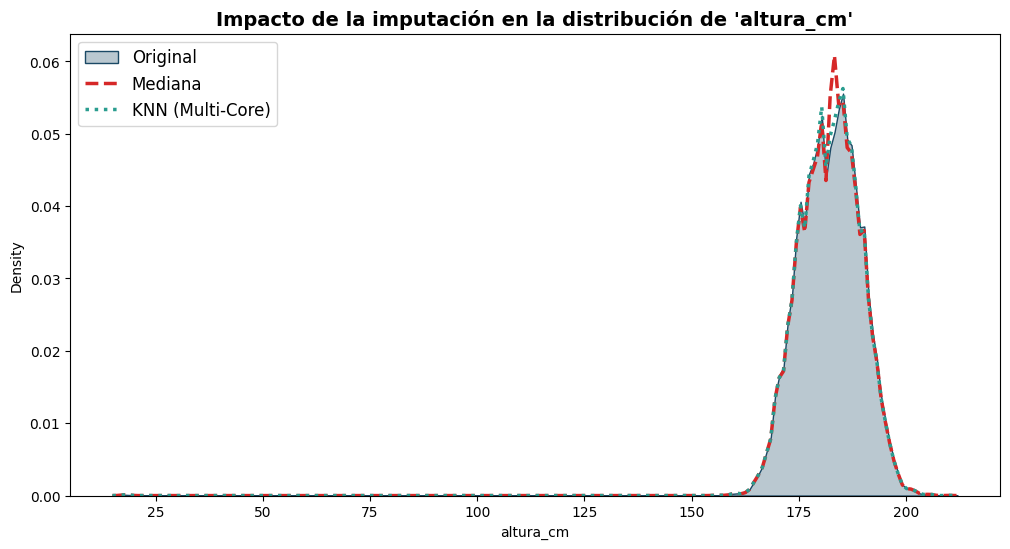


================ Variable: dias_para_fin_contrato ================


,Original (con NAs),Imputado Mediana,Imputado KNN Multi
count,126784.00,144048.00,144048.00
mean,1040.35,1035.27,1032.07
std,590.93,554.56,567.90
min,-8588.00,-8588.00,-8588.00
25%,567.00,642.00,584.00
50%,998.00,998.00,991.00
75%,1470.00,1346.00,1379.00
max,4400.00,4400.00,4400.00


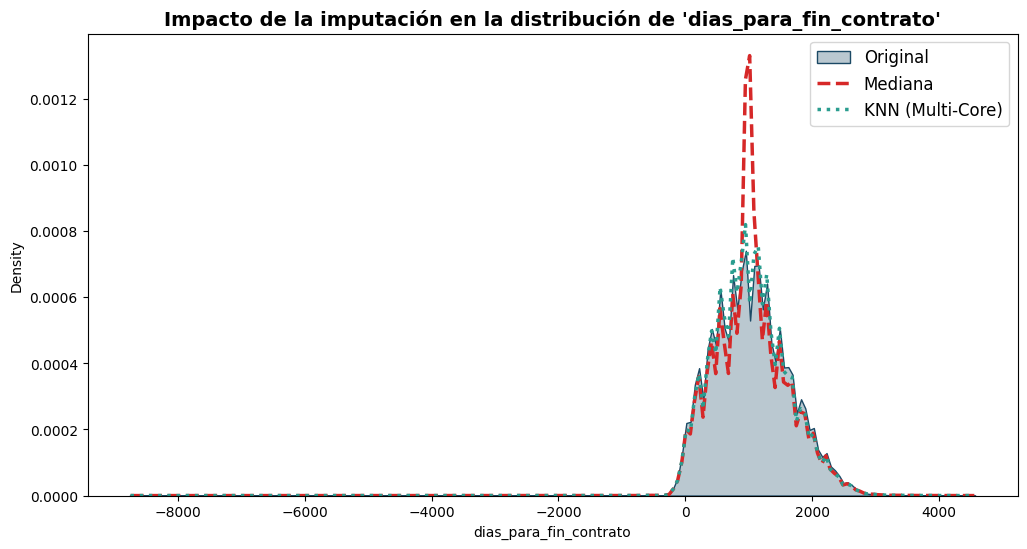

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
# Importes para habilitar el KNN Multihilo
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor

# ==========================================
# 0. IMPUTACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================
print("--- 1. Imputando variables categóricas (Vía Moda) ---")

# 1. Guardamos copias estrictas para graficar el "Antes"
cols_cat = ['pie_habil', 'nacionalidad', 'liga_actual']
df_cat_original = df[cols_cat].copy() if set(cols_cat).issubset(df.columns) else pd.DataFrame()

# 2. Imputación por Moda para TODAS las solicitadas
for col in cols_cat:
    if col in df.columns:
        moda_val = df[col].mode()[0]
        df[col] = df[col].fillna(moda_val)

print("✅ Imputación categórica lista. Nulos restantes:")
print(df[cols_cat].isnull().sum() if not df_cat_original.empty else "Columnas no encontradas.")
print("\n")

# 3. Función de Gráficos Panorámicos Oscuros
def graficar_categorica_completa(columna):
    # Figura vertical gigante para acomodar decenas/cientos de categorías
    fig, axes = plt.subplots(2, 1, figsize=(18, 14)) 
    
    # Ordenamos por las categorías más frecuentes en el original para mantener consistencia
    orden = df_cat_original[columna].fillna('FALTANTES').value_counts().index
    
    # Gráfico 1: Antes (Azul oscuro profundo)
    sns.countplot(
        data=df_cat_original.fillna({columna: 'FALTANTES'}), 
        x=columna, 
        ax=axes[0], 
        order=orden, 
        color='#023047' 
    )
    axes[0].set_title(f'ANTES: {columna} (Con Nulos)', fontsize=16, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].set_ylabel('Cantidad')
    
    # Gráfico 2: Después (Rojo oscuro profundo)
    sns.countplot(
        data=df, 
        x=columna, 
        ax=axes[1], 
        order=orden, 
        color='#780000' 
    )
    axes[1].set_title(f'DESPUÉS: {columna} (Imputado con Moda)', fontsize=16, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[1].set_ylabel('Cantidad')
    
    plt.tight_layout()
    plt.show()

# Lanzar los gráficos si las columnas existen
if not df_cat_original.empty:
    for col in cols_cat:
        graficar_categorica_completa(col)

# ==========================================
# 1. IDENTIFICAR VALORES FALTANTES (NUMÉRICAS)
# ==========================================
print("--- 2. Conteo de Valores Faltantes (Numéricas) ---")
faltantes = df.isnull().sum()
faltantes_cols = faltantes[faltantes > 0]

if faltantes_cols.empty:
    print("¡No hay valores faltantes numéricos en el dataset!")
else:
    print(faltantes_cols)
    print(f"\nPorcentaje de datos faltantes:\n{(faltantes_cols / len(df) * 100).round(2)}%")

# Salvavidas para memoria del Notebook
if 'num_cols' not in locals():
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cols_imputar = [col for col in faltantes_cols.index if col in num_cols]

if cols_imputar:
    # ==========================================
    # 2. APLICAR DOS MÉTODOS DE IMPUTACIÓN
    # ==========================================
    print("\n--- 3. Iniciando imputación de variables numéricas ---")
    
    df_imputado_mediana = df.copy()
    df_imputado_knn = df.copy()
    
    # Método A: Mediana
    imputer_mediana = SimpleImputer(strategy='median')
    df_imputado_mediana[cols_imputar] = imputer_mediana.fit_transform(df[cols_imputar])
    
    # Método B: KNN Multihilo (Uso de todos los núcleos del CPU)
    print("⏳ Calculando KNN usando todos los núcleos del procesador (n_jobs=-1)...")
    imputer_avanzado = IterativeImputer(
        estimator=KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        max_iter=10,
        random_state=42
    )
    df_imputado_knn[cols_imputar] = imputer_avanzado.fit_transform(df[cols_imputar])
    print("✅ Imputación numérica multihilo finalizada.")

    # ==========================================
    # 3. COMPARAR RESULTADOS (Antes y Después)
    # ==========================================
    print("\n--- 4. Comparación de Estadísticas Descriptivas ---")
    for col in cols_imputar:
        print(f"\n================ Variable: {col} ================")
        comp_df = pd.DataFrame({
            'Original (con NAs)': df[col].describe(),
            'Imputado Mediana': df_imputado_mediana[col].describe(),
            'Imputado KNN Multi': df_imputado_knn[col].describe()
        })
        display(comp_df.round(2))
        
        # Comparación visual (KDE con colores oscuros y marcados)
        plt.figure(figsize=(12, 6))
        sns.kdeplot(data=df, x=col, label='Original', fill=True, alpha=0.3, color='#1b4965')
        sns.kdeplot(data=df_imputado_mediana, x=col, label='Mediana', fill=False, color='#d62828', linewidth=2.5, linestyle='--')
        sns.kdeplot(data=df_imputado_knn, x=col, label='KNN (Multi-Core)', fill=False, color='#2a9d8f', linewidth=2.5, linestyle=':')
        
        plt.title(f"Impacto de la imputación en la distribución de '{col}'", fontsize=14, fontweight='bold')
        plt.legend(fontsize=12)
        plt.show()

# 9. Conclusiones Finales del Análisis Exploratorio (EDA)

A partir de las pruebas de asociación y dependencia, se extraen las siguientes conclusiones determinantes para la fase de modelado predictivo:

* **La "Inercia" del Mercado:** La correlación de Spearman confirma contundentemente la Hipótesis 1. El `valor_maximo_historico_previo` es, con muchísima diferencia, el mejor predictor numérico del valor actual (0.82). Así el mercado futbolístico tiene una fuerte memoria estocástica; el estatus previo de un jugador amortigua las caídas de precio frente a un mal rendimiento reciente o posterior.

* **Regularidad vs. Explosividad:** variables de volumen de juego (`partidos_jugados_12m`, `minutos_jugados_12m` con ~0.52) tienen mayor correlación con el precio que las variables de acierto directo (`goles_12m`, `asistencias_12m` con ~0.45). El mercado valora más la consistencia y la disponibilidad física que los destellos puntuales.

* **Desmitificación de variables físicas y demográficas:** Atributos como la `altura_cm` (-0.04) o el `mes_de_nacimiento` (0.02) son irrelevantes a la hora de explicar la varianza del precio, descartando efectos como el sesgo de edad relativa en el mercado de élite.

* **El Contexto como Multiplicador del Valor:** La prueba de Kruskal-Wallis arrojó un p-valor de 0.0 para todas las variables categóricas (`liga_actual`, `nacionalidad`, `posicion_principal`). Esto valida la Hipótesis 3: el valor de un jugador no es un atributo numérico aislado de su rendimiento, sino una construcción fuertemente segmentada por la jerarquía económica de la liga en la que juega y posiblemente la escasez táctica de su rol.

* **Tratamiento de nulos en variables cualitativas:** la ausencia de información puede ser un dato en sí mismo. En el caso de liga_actual (16.25% de nulos), evitar la imputación por Moda y optar por una categoría constante (`Sin Equipo`) fue crucial para no inflar artificialmente el valor de agentes libres asignándoles ligas de élite. Por otro lado, la imputación por Moda en `pie_habil` y `nacionalidad` asumió una distribución alineada a la mayoría poblacional
